In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [66]:
from sklearn.datasets import make_classification


In [68]:
x,y = make_classification(n_samples= 1000,n_features = 5,n_informative = 4,n_redundant = 0)

In [131]:
df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['output'] = y
print(df.shape)
df.head()

(1000, 6)


,col1,col2,col3,col4,col5,output
0,-1.222834,-0.023103,0.841192,2.248521,-0.846302,0
1,2.125353,2.070675,-0.706945,1.103497,-0.196354,1
2,0.106505,0.185599,0.019055,0.888142,-1.117828,1
3,-0.288527,-1.072236,0.422385,1.069060,0.546157,1
4,0.824146,-0.628500,-0.823661,-1.099321,2.384220,0


In [133]:
#feature_sampling
def row_sampling(df,percent):
    return df.sample(int(percent*df.shape[0]),replace =True)

In [141]:
def feature_sampling(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols].copy()
    new_df['target'] = df['output']
    return new_df

In [143]:
def combined_sampling(df,row_percent,col_percent):
    new_df = row_sampling(df,row_percent)
    return feature_sampling(new_df,col_percent)

In [210]:
df1 = combined_sampling(df,0.5,0.8)
print(df1)

         col4      col1      col3      col2  target
423  1.389795 -1.343144  0.376321  1.079585       1
556 -1.718515  2.156005  2.297875  0.975701       0
714  0.973784  1.992280  1.170936  0.168074       0
299  0.650513 -1.751050  1.515526 -0.878024       1
100 -1.080600 -0.095509 -0.264320  0.649089       0
..        ...       ...       ...       ...     ...
140  1.306308  2.296042  2.314841  0.022181       0
823  2.123324  0.448424  1.247441 -0.736599       1
330  0.209247 -1.511584 -1.131121 -1.068849       1
411 -0.697902  0.912783  0.881626  0.903986       0
970  2.379817 -0.962824 -0.971975  1.086955       1

[500 rows x 5 columns]


In [212]:
df2 = combined_sampling(df,0.5,0.8)
print(df3)

         col3      col4      col2      col5  target
171 -0.162211  2.168200 -0.672855  1.258091       0
512  1.641844  1.531351 -0.332649 -0.726158       0
921 -0.332613 -1.828563  0.691066  3.224241       0
611  0.781325 -2.747603  2.297843  3.004020       0
358  3.243560 -0.723589 -1.721328  1.058302       0
..        ...       ...       ...       ...     ...
410 -1.157853 -0.216230 -3.011217  0.742145       0
822 -0.021937  1.741228  2.299694 -0.375819       1
710 -1.659284 -1.427512  3.102617  0.120094       0
533 -0.369577 -1.648042  2.382443  0.095701       0
439  0.828183 -0.817072  1.051883  0.852880       0

[500 rows x 5 columns]


In [214]:
df3 = combined_sampling(df,0.5,0.8)
print(df3)

         col5      col1      col4      col3  target
576  2.408740  3.188113  1.632312  1.173036       0
2   -1.117828  0.106505  0.888142  0.019055       1
128 -0.082176 -0.178316  0.440408 -0.031183       0
881 -1.185576  1.121056  0.133668 -0.864691       1
893 -0.154560 -2.302504  0.073795  0.898918       1
..        ...       ...       ...       ...     ...
159  1.011043 -0.332345  1.473491  1.083169       0
561  1.157192 -1.651271  0.876046 -0.466738       1
113 -0.469377  0.217775 -1.118970 -0.083867       0
65   2.015109  2.521152  1.393255 -0.076929       0
322  0.293394 -2.322572  0.156083  1.676436       1

[500 rows x 5 columns]


In [186]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col2', 'col5', 'col4', 'target'], dtype='str')
Index(['col2', 'col5', 'col4', 'col3', 'target'], dtype='str')
Index(['col3', 'col4', 'col2', 'col5', 'target'], dtype='str')


In [188]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()

In [190]:
clf2 = DecisionTreeClassifier()

In [192]:
clf3 = DecisionTreeClassifier()

In [224]:
df1.iloc[:,0:4]

,col4,col1,col3,col2
423,1.389795,-1.343144,0.376321,1.079585
556,-1.718515,2.156005,2.297875,0.975701
714,0.973784,1.992280,1.170936,0.168074
299,0.650513,-1.751050,1.515526,-0.878024
100,-1.080600,-0.095509,-0.264320,0.649089
...,...,...,...,...
140,1.306308,2.296042,2.314841,0.022181
823,2.123324,0.448424,1.247441,-0.736599
330,0.209247,-1.511584,-1.131121,-1.068849
411,-0.697902,0.912783,0.881626,0.903986


In [226]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df2.iloc[:,0:4],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [228]:
from sklearn.tree import plot_tree

[Text(0.3801229508196721, 0.9642857142857143, 'x[1] <= -0.149\ngini = 0.499\nsamples = 500\nvalue = [241, 259]'),
 Text(0.1362704918032787, 0.8928571428571429, 'x[0] <= 0.416\ngini = 0.343\nsamples = 182\nvalue = [40, 142]'),
 Text(0.2581967213114754, 0.9285714285714286, 'True  '),
 Text(0.04918032786885246, 0.8214285714285714, 'x[3] <= 1.796\ngini = 0.069\nsamples = 56\nvalue = [2, 54]'),
 Text(0.03278688524590164, 0.75, 'x[3] <= -0.672\ngini = 0.036\nsamples = 55\nvalue = [1, 54]'),
 Text(0.01639344262295082, 0.6785714285714286, 'gini = 0.0\nsamples = 49\nvalue = [0, 49]'),
 Text(0.04918032786885246, 0.6785714285714286, 'x[0] <= 0.151\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.03278688524590164, 0.6071428571428571, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.06557377049180328, 0.6071428571428571, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.06557377049180328, 0.75, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.22336065573770492, 0.8214285714285714, 'x[

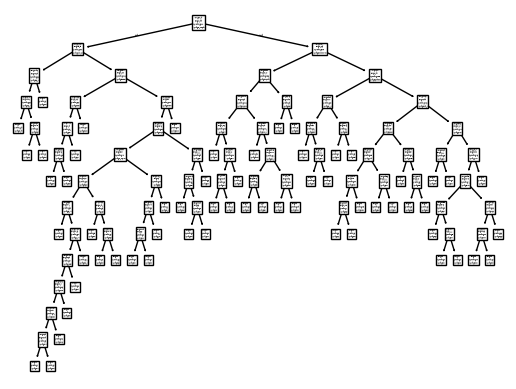

In [230]:
plot_tree(clf1)

[Text(0.49673507462686567, 0.96875, 'x[1] <= 0.152\ngini = 0.498\nsamples = 500\nvalue = [266, 234]'),
 Text(0.2736318407960199, 0.90625, 'x[2] <= 1.435\ngini = 0.423\nsamples = 217\nvalue = [66, 151]'),
 Text(0.3851834577114428, 0.9375, 'True  '),
 Text(0.15920398009950248, 0.84375, 'x[2] <= -1.332\ngini = 0.39\nsamples = 203\nvalue = [54, 149]'),
 Text(0.08955223880597014, 0.78125, 'x[1] <= -0.483\ngini = 0.472\nsamples = 21\nvalue = [13, 8]'),
 Text(0.06965174129353234, 0.71875, 'x[0] <= 0.281\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(0.04975124378109453, 0.65625, 'x[2] <= -2.686\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.029850746268656716, 0.59375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.06965174129353234, 0.59375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.08955223880597014, 0.65625, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.10945273631840796, 0.71875, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.22885572139303484, 0.7

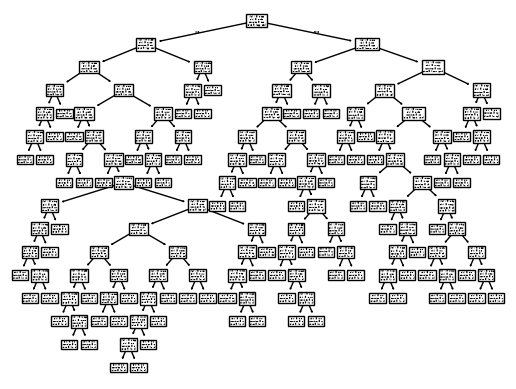

In [231]:
plot_tree(clf2)

[Text(0.8736413668279779, 0.9838709677419355, 'x[2] <= 2.084\ngini = 0.499\nsamples = 500\nvalue = [240, 260]'),
 Text(0.7918032816011612, 0.9516129032258065, 'x[0] <= 3.421\ngini = 0.5\nsamples = 489\nvalue = [238.0, 251.0]'),
 Text(0.8327223242145696, 0.967741935483871, 'True  '),
 Text(0.7120312207365689, 0.9193548387096774, 'x[1] <= 1.39\ngini = 0.5\nsamples = 481\nvalue = [237, 244]'),
 Text(0.5730350442128639, 0.8870967741935484, 'x[0] <= 3.003\ngini = 0.498\nsamples = 341\nvalue = [159, 182]'),
 Text(0.5661857291443707, 0.8548387096774194, 'x[1] <= 1.055\ngini = 0.497\nsamples = 336\nvalue = [154, 182]'),
 Text(0.4953851569188784, 0.8225806451612904, 'x[2] <= 1.249\ngini = 0.499\nsamples = 305\nvalue = [146, 159]'),
 Text(0.4051538754815925, 0.7903225806451613, 'x[3] <= 2.251\ngini = 0.497\nsamples = 281\nvalue = [129, 152]'),
 Text(0.2966091208261986, 0.7580645161290323, 'x[1] <= 1.042\ngini = 0.493\nsamples = 260\nvalue = [115, 145]'),
 Text(0.2897598057577055, 0.7258064516129

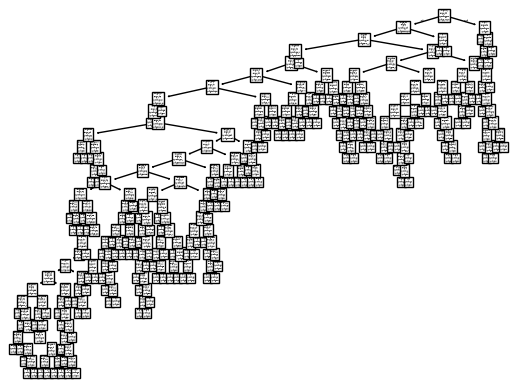

In [232]:
plot_tree(clf3)

In [235]:
clf1.predict( np.array([1.389795, -1.343144 , 0.376321,  1.079585]).reshape(1,4))

C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [237]:
clf2.predict( np.array([1.389795, -1.343144 , 0.376321,  1.079585]).reshape(1,4))

C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [238]:
clf3.predict( np.array([1.389795, -1.343144 , 0.376321,  1.079585]).reshape(1,4))

C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])